In [1]:
import sys, os
sys.path.insert(1, '../..')

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import networkx as nx
import pickle
from itertools import combinations
import config.config as conf

In [3]:
net_result = f'{conf.DATA_PATH}{conf.NETWORK_RESULT}'
net_src = f'{conf.DATA_PATH}{conf.NETWORK_SRC}'


In [4]:
file_list = sorted(os.listdir(f'{net_src}'))

In [ ]:
file_list

['qna_2122.csv', 'qna_2124.csv', 'qna_2223.csv', 'qna_2324.csv']

In [6]:
df_dict = {
'2021~2022' : pd.read_csv(f'{net_src}/{file_list[0]}', index_col=False),
'2022~2023' : pd.read_csv(f'{net_src}/{file_list[2]}', index_col=False),
'2023~2024' : pd.read_csv(f'{net_src}/{file_list[3]}', index_col=False)
}

In [7]:
def get_network(df) : 
    node = np.unique(np.append(df['Source'].values, df['Target'].values))
    edgelist = list(zip(df['Source'], df['Target']))

    G = nx.DiGraph()
    G.add_nodes_from(node)
    G.add_edges_from(edgelist)
    return G

In [8]:
g_dict = {key:get_network(df) for key, df in df_dict.items()}

In [9]:
triadic_dict = {key:nx.triadic_census(g) for key, g in g_dict.items()}

In [10]:
triadic_p_dict = { keys : { v_keys: v_values/(sum(values_dicts.values())) for v_keys, v_values in values_dicts.items()} for keys, values_dicts in triadic_dict.items() }

In [11]:
tot_df = pd.DataFrame()

for key in triadic_p_dict.keys():
    print(key)
    col = ['year', 'type', 'proportion']
    tot_df = pd.concat([tot_df, \
                        pd.DataFrame(zip([key]*16, triadic_p_dict[key].keys(), triadic_p_dict[key].values()), columns = col).pivot(index='year', columns = 'type', values = 'proportion')],\
                        axis = 0)

2021~2022
2022~2023
2023~2024


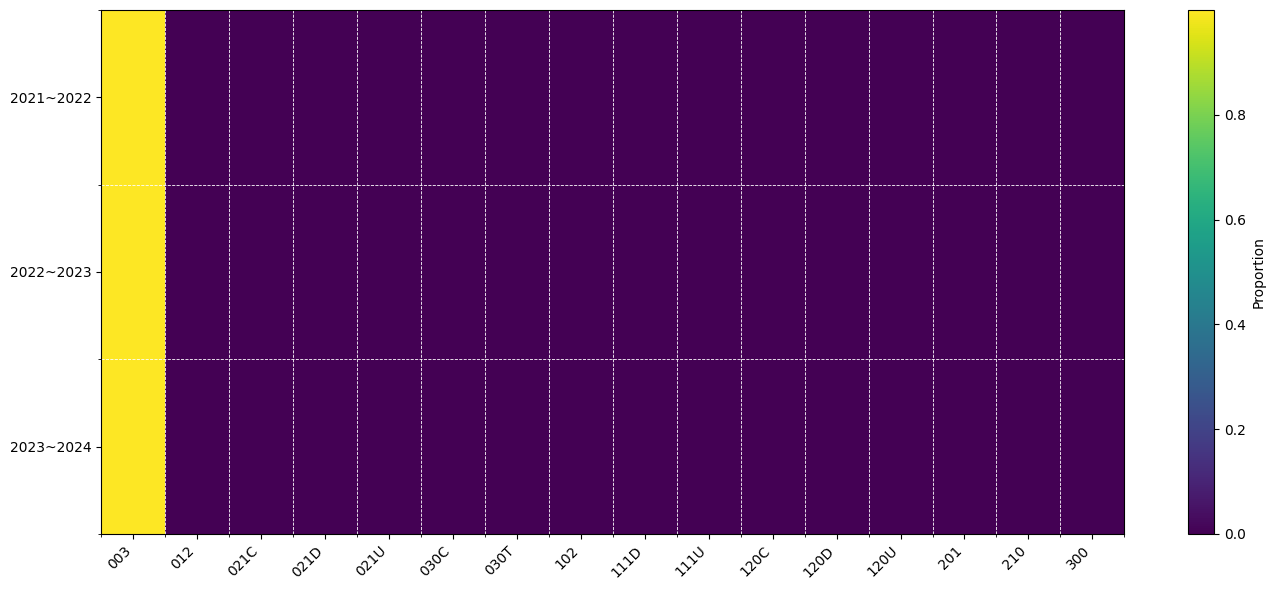

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(14, 6), sharex=True)

cmap = plt.cm.viridis
all_values = tot_df.values.flatten()

norm = mcolors.Normalize(
    vmin=0,
    vmax=all_values.max()
)

im = ax.imshow(
    tot_df.values,
    aspect="auto",
    cmap=cmap,
    norm=norm
)


# x축: triad types
ax.set_xticks(range(len(tot_df.columns)))
ax.set_xticklabels(tot_df.columns, rotation=45, ha="right")

# y축: 연도
ax.set_yticks(range(len(tot_df.index)))
ax.set_yticklabels(tot_df.index)

n_rows, n_cols = tot_df.shape

# 셀 경계에 minor tick 배치
ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)

# minor grid를 실제 격자로 사용
ax.grid(
    which="minor",
    color="white",     # 배경이 어두우면 white, 밝으면 black
    linestyle="--",
    linewidth=0.6
)

# minor 


fig.colorbar(im, ax=ax, label="Proportion")
plt.tight_layout()
plt.savefig(f"Result_Fig5.png", dpi=300, bbox_inches='tight')
plt.show()


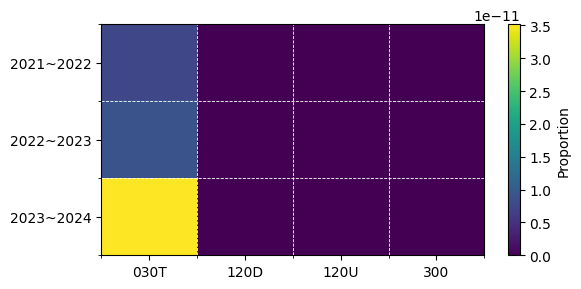

In [ ]:
df_trans = tot_df[['030T', '120D', '120U', '300']]

fig, ax = plt.subplots(figsize=(6, 3))

im = ax.imshow(
    df_trans.values,
    aspect='auto',
    cmap=cmap,
    norm=mcolors.Normalize(
        vmin=df_trans.values.min(),
        vmax=df_trans.values.max()
    )
)

ax.set_xticks(range(len(df_trans.columns)))
ax.set_xticklabels(df_trans.columns)
ax.set_yticks(range(len(df_trans.index)))
ax.set_yticklabels(df_trans.index)

n_rows, n_cols = df_trans.shape

# 셀 경계에 minor tick 배치
ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)

# minor grid를 실제 격자로 사용
ax.grid(
    which="minor",
    color="white",     # 배경이 어두우면 white, 밝으면 black
    linestyle="--",
    linewidth=0.6
)


plt.colorbar(im, ax=ax, label='Proportion')
plt.tight_layout()
plt.savefig(f"Result_Fig6.png", dpi=300, bbox_inches='tight')
plt.show()
